# Investigating a Deployed ML Model via API

**Working Example.** Copy this file, rename it (replace _case with your alias), and modify your copy.

See docs/your-files.md for more information. 

Do not edit this example.
It should stay runnable and available as a reference
until after your work has been assessed. 

Your notebook should reflect your name (or alias), the date, your dataset, and your target in the opening below.

- Author: Denise Case
- Date: 2026-06
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M7. Investigating a Deployed Model

This notebook calls a live prediction API and hits it systematically.
The model is already trained and served. 

Your job is to understand its behavior by varying inputs and observing what changes. 

**Your judgment** is what you conclude about where the model is confident, 
where it is fragile, and why.

No model training is required. The API is already live.

## A. Prepare the Project Environment (.venv/)

- Open **only one project in VS Code at a time**.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.


## M7. Probing a Model from the Outside

Once a model is deployed, you cannot always see inside it.
But you can learn a great deal by asking it questions systematically:

- **Vary one feature at a time** and watch predictions change.
  This reveals which inputs the model is most sensitive to.
- **Test edge cases** - try values outside the training range, missing fields,
  extreme numbers and observe how the API responds.
- **Build a prediction grid** over two features at once and visualize
  the decision boundary as a heatmap.

Naming what you observe and what it implies about the model is the
judgment this module adds. 
The API call is just a function.

## Section 1. Project Setup and Imports

In [7]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Any  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07", level="DEBUG")
log_header(LOG, "M07")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  requests:     {version('requests')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Section 1e. GLOBAL CONSTANTS ===

# CUSTOM: update this URL if you deploy your own model.
API_URL: str = "https://ml-penguin-predictor.onrender.com/predict"
LOG.info(f"API endpoint: {API_URL}")

2026-06-28 14:33:23 | INFO | M07 | === RUN START ===
2026-06-28 14:33:23 | INFO | M07 | project=M07
2026-06-28 14:33:23 | INFO | M07 | repo_dir=ml-07-applied
2026-06-28 14:33:23 | INFO | M07 | python=3.14.0
2026-06-28 14:33:23 | INFO | M07 | os=Windows 11
2026-06-28 14:33:23 | INFO | M07 | shell=powershell
2026-06-28 14:33:23 | INFO | M07 | cwd=notebooks
2026-06-28 14:33:23 | INFO | M07 | github_actions=False
2026-06-28 14:33:23 | INFO | M07 | Confirming installation:
2026-06-28 14:33:23 | INFO | M07 |   python:       3.14.0
2026-06-28 14:33:23 | INFO | M07 |   pandas:       3.0.4
2026-06-28 14:33:23 | INFO | M07 |   numpy:        2.5.0
2026-06-28 14:33:23 | INFO | M07 |   matplotlib:   3.11.0
2026-06-28 14:33:23 | INFO | M07 |   seaborn:      0.13.2
2026-06-28 14:33:23 | INFO | M07 |   requests:     2.34.2
2026-06-28 14:33:23 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict


## Section 2. Baseline Predictions

```text
ANALYST CHOICE
Before investigating, confirm the API returns expected results for
known inputs. If these baseline calls fail, the investigation cannot proceed.
```

In [8]:
# === Section 2. Baseline Predictions ===


def predict(payload: dict[str, Any]) -> str:
    """Send a payload to the prediction API and return the predicted species.

    WHY: A single reusable function keeps all API calls consistent.
    Any change to the endpoint or headers only needs to happen here.

    Args:
        payload: dict of feature name -> value.

    Returns:
        Predicted species string, or an error message string.
    """
    try:
        response = requests.post(API_URL, json=payload, timeout=30)
        response.raise_for_status()
        return str(response.json().get("prediction", "NO_PREDICTION_KEY"))
    except requests.exceptions.Timeout:
        return "TIMEOUT (server may be sleeping - try again)"
    except requests.exceptions.RequestException as exc:
        return f"ERROR: {exc}"


# One known example per species from the penguins dataset.
BASELINES: list[dict[str, Any]] = [
    {
        "bill_length_mm": 39.1,
        "bill_depth_mm": 18.7,
        "flipper_length_mm": 181,
        "body_mass_g": 3750,
    },
    {
        "bill_length_mm": 46.5,
        "bill_depth_mm": 17.9,
        "flipper_length_mm": 192,
        "body_mass_g": 3500,
    },
    {
        "bill_length_mm": 46.1,
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211,
        "body_mass_g": 4500,
    },
]
EXPECTED: list[str] = ["Adelie", "Chinstrap", "Gentoo"]

LOG.info("Baseline predictions:")
for payload, expected in zip(BASELINES, EXPECTED, strict=True):
    result = predict(payload)
    match = "OK" if result == expected else "MISMATCH"
    LOG.info(f"  expected={expected:<10} got={result:<10} [{match}]")

2026-06-28 14:33:23 | INFO | M07 | Baseline predictions:
2026-06-28 14:33:24 | INFO | M07 |   expected=Adelie     got=Adelie     [OK]
2026-06-28 14:33:25 | INFO | M07 |   expected=Chinstrap  got=Chinstrap  [OK]
2026-06-28 14:33:25 | INFO | M07 |   expected=Gentoo     got=Gentoo     [OK]


## Section 3. Feature Sensitivity

```text
ANALYST CHOICE
Vary one feature at a time while holding others fixed.
Observe where the prediction changes. That boundary is the model's
decision for that feature. Decide which features matter most.
```

2026-06-28 14:33:36 | INFO | M07 | bill_length_mm sweep:
2026-06-28 14:33:36 | INFO | M07 |  bill_length_mm prediction
      30.000000     Adelie
      31.578947     Adelie
      33.157895     Adelie
      34.736842     Adelie
      36.315789     Adelie
      37.894737     Adelie
      39.473684     Adelie
      41.052632     Adelie
      42.631579  Chinstrap
      44.210526  Chinstrap
      45.789474  Chinstrap
      47.368421  Chinstrap
      48.947368  Chinstrap
      50.526316  Chinstrap
      52.105263  Chinstrap
      53.684211  Chinstrap
      55.263158  Chinstrap
      56.842105  Chinstrap
      58.421053  Chinstrap
      60.000000  Chinstrap


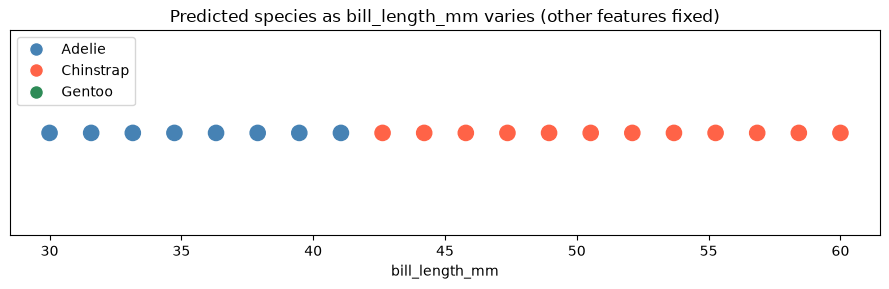

2026-06-28 14:33:36 | INFO | M07 | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [ ]:
# === Section 3. Feature Sensitivity ===


def sweep_feature(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# Use the Adelie baseline and sweep bill_length_mm.
BASE: dict[str, Any] = BASELINES[0]
bill_lengths = list(np.linspace(30, 60, 20))
df_sweep = sweep_feature(BASE, "bill_length_mm", bill_lengths)

LOG.info("bill_length_mm sweep:")
LOG.info(df_sweep.to_string(index=False))

# Plot prediction vs feature value.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}
colors = df_sweep["prediction"].map(color_map).fillna("gray")

plt.figure(figsize=(9, 3))
plt.scatter(df_sweep["bill_length_mm"], [1] * len(df_sweep), c=colors, s=120)
plt.xlabel("bill_length_mm")
plt.yticks([])
plt.title("Predicted species as bill_length_mm varies (other features fixed)")
handles = [
    plt.Line2D(  # pyright: ignore[reportPrivateImportUsage]
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=color_map[s],
        markersize=10,
        label=s,
    )
    for s in species_order
]
plt.legend(handles=handles, loc="upper left")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

## Task: Interpret and Extend Section 3

**Required: Run and interpret:**

Run the sweep above and answer in your notebook (a markdown cell is fine):

1. At what value of `bill_length_mm` does the prediction first shift away from Adelie?
2. Does it shift again? To which species?
3. Does this boundary make sense given what you know about penguins?

**Optional: Extend for deeper insight:**

Try one or more of the following and add your chart and interpretation:

- Sweep a different feature (`bill_depth_mm`, `flipper_length_mm`, or `body_mass_g`)
  using the same `sweep_feature()` function. Which feature produces the sharpest boundary?
- Change `BASE` to the Chinstrap or Gentoo baseline and re-run the same sweep.
  Does the boundary shift? Why might it?
- Sweep the same feature across a finer range (increase `20` to `50`) near the
  boundary you found. Can you pin down the exact transition point?

Don't try to do all of these. 
Pick one, observe something specific,
and explain what it tells you about the model.

## Section 4. Prediction Grid

```text
ANALYST CHOICE
Vary two features together and visualize the 2D decision surface.
Choose the two features you think matter most based on Section 3.
```

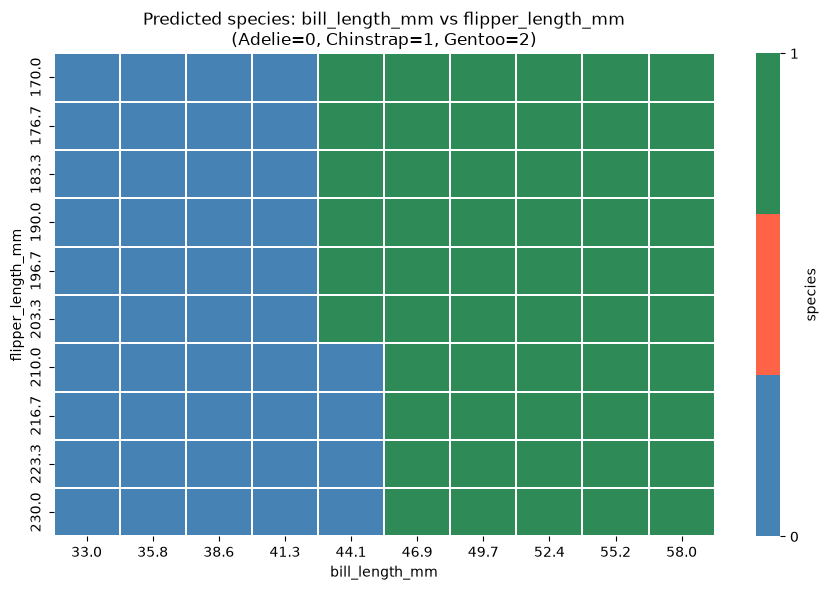

2026-06-28 14:34:28 | INFO | M07 | ANALYST CHOICE: What does the boundary shape tell you about the model?


In [10]:
# === Section 4. Prediction Grid ===

# CUSTOM: adjust ranges based on your investigation in Section 3.
bill_length_values = list(np.linspace(33, 58, 10))
flipper_length_values = list(np.linspace(170, 230, 10))

rows = []
for bl in bill_length_values:
    for fl in flipper_length_values:
        payload = {**BASE, "bill_length_mm": bl, "flipper_length_mm": fl}
        rows.append(
            {
                "bill_length_mm": round(bl, 1),
                "flipper_length_mm": round(fl, 1),
                "prediction": predict(payload),
            }
        )

df_grid = pd.DataFrame(rows)
species_to_int = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
df_grid["species_int"] = df_grid["prediction"].map(species_to_int).fillna(-1)

pivot = df_grid.pivot(
    index="flipper_length_mm",
    columns="bill_length_mm",
    values="species_int",
)

plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    cmap=["steelblue", "tomato", "seagreen"],
    linewidths=0.3,
    cbar_kws={"ticks": [0, 1, 2], "label": "species"},
)
plt.title(
    "Predicted species: bill_length_mm vs flipper_length_mm\n(Adelie=0, Chinstrap=1, Gentoo=2)"
)
plt.tight_layout()
plt.show()

LOG.info("ANALYST CHOICE: What does the boundary shape tell you about the model?")

## Section 5. Edge Cases

```text
ANALYST CHOICE
What happens with unusual or invalid inputs?
A robust API should handle bad input gracefully.
Decide if this one does.
```

In [11]:
# === Section 5. Edge Cases ===

edge_cases: list[tuple[str, dict[str, Any]]] = [
    (
        "missing feature",
        {"bill_length_mm": 39.1, "bill_depth_mm": 18.7, "flipper_length_mm": 181},
    ),
    (
        "extreme bill length",
        {
            "bill_length_mm": 1.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "very large bill",
        {
            "bill_length_mm": 999.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "negative value",
        {
            "bill_length_mm": -10.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "zero body mass",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 0,
        },
    ),
]

LOG.info("Edge case results:")
for label, payload in edge_cases:
    result = predict(payload)
    LOG.info(f"  {label:<22} -> {result}")

LOG.info("ANALYST CHOICE: Which edge cases were handled cleanly and which were not?")

2026-06-28 14:34:28 | INFO | M07 | Edge case results:
2026-06-28 14:34:29 | INFO | M07 |   missing feature        -> ERROR: 400 Client Error: Bad Request for url: https://ml-penguin-predictor.onrender.com/predict
2026-06-28 14:34:29 | INFO | M07 |   extreme bill length    -> Adelie
2026-06-28 14:34:30 | INFO | M07 |   very large bill        -> Chinstrap
2026-06-28 14:34:30 | INFO | M07 |   negative value         -> Adelie
2026-06-28 14:34:31 | INFO | M07 |   zero body mass         -> Adelie
2026-06-28 14:34:31 | INFO | M07 | ANALYST CHOICE: Which edge cases were handled cleanly and which were not?


## Section 6. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [12]:
# === Section 6. Summary ===


def summarize() -> None:
    """Record what was investigated and the judgment still owed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"API endpoint: {API_URL}")
    LOG.info("========================")


summarize()

2026-06-28 14:34:31 | INFO | M07 | ========================
2026-06-28 14:34:31 | INFO | M07 | SUMMARY
2026-06-28 14:34:31 | INFO | M07 | ========================
2026-06-28 14:34:31 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict
2026-06-28 14:34:31 | INFO | M07 | ========================


### Narrative

Summarize your work in this Markdown cell in your notebook.

Investigations completed:

1. Baseline predictions confirmed
2. Feature sensitivity sweep (bill_length_mm)
3. Prediction grid (bill_length_mm x flipper_length_mm)
4. Edge case testing

YOUR JUDGMENT (write up in README.md and docs/index.md):

- Which features had the most influence on predictions?
- Where did you observe a decision boundary shift?
- Which edge cases were handled well and which were not?
- What would you change about the API contract?

### Conclusions

This is SUPERVISED learning (because the model was trained with a target).

The target is `species`, a category column, so the model performs classification.

We investigated the model's behavior from the outside by varying inputs and observing predictions.

### Next Steps

Summarize your next steps in this Markdown cell in your notebook.


## Task: Make the Notebook Yours (Apply / Extend / Explore)

This is an example.
Copy this notebook and make it your own.

In your copy:

1. At the beginning, update the Author, the API URL, the target, etc.
2. Remove any instructions you do not need.

Try things like the following.

1. **Apply** - Sweep a different feature (bill_depth_mm or body_mass_g) and add its chart alongside Section 3. Report which feature produced the sharpest boundary.
2. **Extend** - Point `API_URL` at your own deployed model (Hugging Face or Render) and repeat the investigation. Do the boundaries shift?
3. **Explore** - Add a third feature to the grid (a 3D sweep collapsed to a facet grid) and decide whether the extra complexity revealed anything new.

**Assessed:** `README.md` and `docs/index.md` - your investigation, your charts,
and your account of what the model's behavior tells you. Keep this example alongside
your work until assessed.

## Task: Final Check

- `README.md` - reflects your description, instructions, commands, and links to your executed notebook.
- `docs/index.md` - reflects your project-specific updates.
- Your GitHub **About** section has a link to your hosted documentation site.
- The executed example notebook AND your custom notebook are available in `notebooks/`.
- Keep this **working example** alongside your custom work until your work has been assessed.
- Ensure your **custom notebook** introduces and narrates **your** custom project.

## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
